In [1]:
import pandas as pd

df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
missing = df.isnull().sum()
missing

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [12]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
df_age = df.copy()
# điền age thiếu bằng mean
mean_age = df_age['Age'].mean()
df_age['Age'].fillna(mean_age, inplace=True)
print(df_age['Age'].isnull().sum())


0


In [18]:
from sklearn.impute import KNNImputer
# điền age bị thiếu bằng KNN
df_age = df[['Survived', 'Age', 'Pclass', 'SibSp']].copy()
imputer = KNNImputer(n_neighbors=5)

df_age_clean = pd.DataFrame(imputer.fit_transform(df_age), columns=df_age.columns)

In [19]:
df_age_clean.isnull().sum()

,0
Survived,0
Age,0
Pclass,0
SibSp,0


In [21]:
# tạo cột mới gán nhãn thiếu / không thiếu
df_age = df.copy()
df_age['Age_missing'] = df_age['Age'].isnull().astype(int)
df_age.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_missing
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [26]:
df_clean = df.copy()
# điền age thiếu bằng mean
mean_age = df_age['Age'].mean()
df_clean['Age'].fillna(mean_age, inplace=True)
# xóa cột Cabin
df_clean.drop('Cabin', axis=1, inplace=True)
# điền Embarked thiếu bằng mode
mode_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'].fillna(mode_embarked, inplace=True)


In [27]:
from scipy import stats
Q1_fare = df_clean['Fare'].quantile(0.25)
Q3_fare = df_clean['Fare'].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare
lower = Q1_fare - 1.5 * IQR_fare
upper = Q3_fare + 1.5 * IQR_fare

outliers_fare = df_clean[(df_clean['Fare'] < lower) | (df_clean['Fare'] > upper)]

print(f'Q1 = {Q1_fare:.2f}, Q3 = {Q3_fare:.2f}, IQR = {IQR_fare:.2f}')
print(f'lower = {lower:.2f}, upper = {upper:.2f}')
print(f'Outliers:', len(outliers_fare))

Q1 = 7.91, Q3 = 31.00, IQR = 23.09
lower = -26.72, upper = 65.63
Outliers: 116


In [28]:
# xử lý ngoại lệ bằng clip
df_clean_fare = df_clean.copy()
df_clean_fare['Fare'] = df_clean_fare['Fare'].clip(lower, upper)
print(f'Min fare sau khi clip: {df_clean_fare["Fare"].min()}')
print(f'Max fare sau khi clip: {df_clean_fare["Fare"].max()}')

Min fare sau khi clip: 0.0
Max fare sau khi clip: 65.6344


In [29]:
print(len(df_clean_fare))

891


In [30]:
import numpy as np
# xử lý ngoại lệ bằng log
df_clean_fare = df_clean.copy()
df_clean_fare['Fare'] = np.log1p(df_clean_fare['Fare'])
df_clean_fare.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,2.962246
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,0.969048
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,2.187218
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,2.737881
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,3.465736
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,6.240917


In [31]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
print(df['Title'].value_counts())
print(df['Title'].unique())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64
['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']


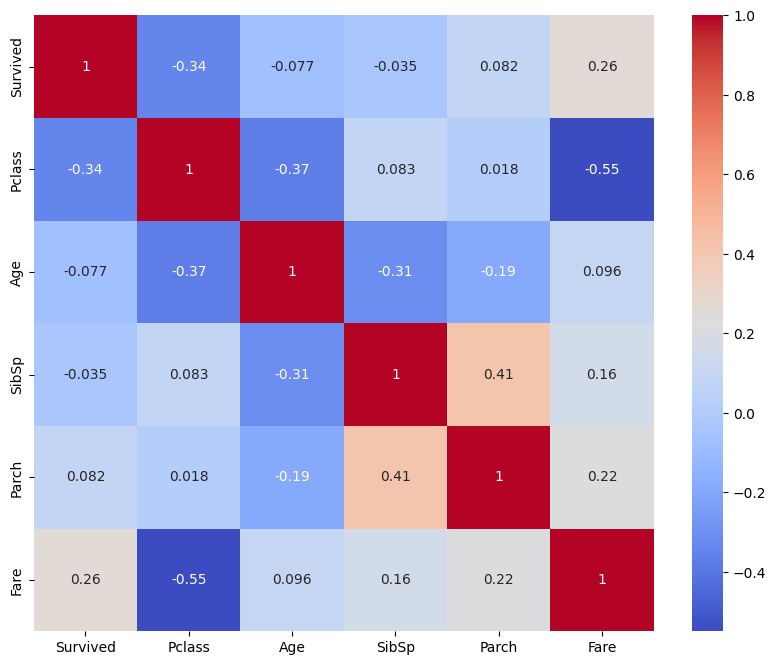

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

num_features = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[num_features].corr()
# heat map
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()